In [1]:

import jax.numpy as jnp

import sys

sys.path.append("../../siegel_analyses/scripts/")
sys.path.insert(1,'../scripts/')

import netrep_helpers as nh
import utils
import loader
import setup
import pickle

import matplotlib.pyplot as plt

import seaborn as sns
%load_ext autoreload
%autoreload 2
import scipy.stats as sts
import numpy as np

import imp
imp.reload(setup)
imp.reload(loader)
imp.reload(utils)
import tqdm
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score
import psychofit as psy

import matplotlib as mpl
new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
mpl.rcParams.update(new_rc_params)

### Functions

In [5]:
def convert_to_rw_choices(cs_trials):
    choices = []
    for subject in cs_trials:
        left = subject[:,:4] == -1
        right = subject[:,5:] == 1
        both = np.column_stack([left.astype(int), right.astype(int)])
        choices.append(np.mean(both,0))
    return np.array(choices)


In [6]:
def fit_psychmetric(cs, n_trials_total=None, dx=0.1):
    # Fit psychometric curves to each session
    contrasts = np.array([-100, -25, -12.5, -6.25, 0., 6.25, 12.5, 25., 100.])
    psym_pars = np.empty((len(cs), 4)) # psychometric parameters
    
    percent_right = np.empty((len(cs), len(contrasts)))

    xx = np.arange(-100, 100, dx)
    fit_curve = np.zeros((len(cs), len(xx)))

    for ii, percent_correct in enumerate(cs):
        """
        # Rempve since im converting to percent correct before
        behavior[behavior == -1] = 0
        percent_correct = np.nanmean(behavior == 1, axis=0)"""

        # Convert to percent choose right
        percent_right[ii,:] = np.hstack((1-percent_correct[contrasts < 0],
                                percent_correct[contrasts >= 0]))

        if n_trials_total is None:
            n_trials = [np.sum(~np.isnan(x)) for x in percent_correct.T]
        else:
            n_trials = [n_trials_total[ii]] * len(contrasts)

        # Format data for mle_fit_psycho
        # Row 1: conditions
        # Row 2: number of trials per condition
        # Row 3: percent left in each condition
        data = np.vstack((
            contrasts,
            n_trials,
            percent_right[ii,:]
        ))

        parmin = np.array([-20, -50, 0, 0])
        parmax = np.array([20, 50, 1, 1])
        psym_pars[ii,:], _ = \
            psy.mle_fit_psycho(data,
                               'erf_psycho_2gammas',
                               nfits=15,
                               parmin = parmin,
                               parmax = parmax)
        
        fit_curve[ii,:] = psy.erf_psycho_2gammas(psym_pars[ii,:], xx)

    return fit_curve, percent_right, psym_pars

def compute_behavioral_distance(cs, n_trials_total):
    fit_curve, percent_right, psycho_params = fit_psychmetric(cs, n_trials_total)

    dist_behavioral = np.array(
        [np.sqrt(np.sum((fit_curve[i,:] - fit_curve[j,:])**2 * 0.1))
        for i in range(len(cs))
        for j in range(len(cs))]).reshape(len(cs), len(cs))

    return dist_behavioral, psycho_params, percent_right



In [7]:

def get_dists(train_fold,test_fold, metric="sigmoid", n_trials_total=None):

    ys,cs = train_fold
    #_,cs = test_fold

    S = len(ys)

    #compute distance matrices
    dist_neural = utils.dsd([
        [ys[i],ys[j]]
        for i in range(len(ys)) 
        for j in range(len(ys))]
    ).reshape(S,S)

    if metric=="sigmoid":
        dist_cc,_,_ = compute_behavioral_distance(cs, n_trials_total=n_trials_total)
    elif metric=="area":
        dist_cc = np.zeros((S,S))

        for i in range(S):
            for j in range(S):
                dist_cc[i,j] = np.mean(np.abs(cs[i]- cs[j]))

    return dist_neural,dist_cc,cs

def get_dists_Walther(train_fold,test_fold):

    ys,cs = train_fold
    ys_,cs_ = test_fold

    S = len(ys)

    #compute distance matrices on each partition
    dist_neural_train = utils.dsd([
        [ys[i],ys[j]]
        for i in range(len(ys)) 
        for j in range(len(ys))]
    ).reshape(S,S)

    dist_cc_train = np.zeros((S,S))

    for i in range(S):
        for j in range(S):
            dist_cc_train[i,j] = np.mean(np.abs(cs[i]- cs[j]))  

    # Other partition
    dist_neural_test = utils.dsd([
        [ys_[i],ys_[j]]
        for i in range(len(ys_)) 
        for j in range(len(ys_))]
    ).reshape(S,S)

    dist_cc_test = np.zeros((S,S))  

    for i in range(S):
        for j in range(S):
            dist_cc_test[i,j] = np.mean(np.abs(cs_[i]- cs_[j]))  

    dist_neural = dist_neural_test * dist_neural_train
    dist_cc = dist_cc_test * dist_cc_train  

    return dist_neural,dist_cc,cs

def get_kneigh_decreasing(dist_neural,cs,S=10,W=2):
    """
    Compute the correlation between each subject behavior and average of the top K=2 neighbors in neural space
    cs: list of behavioral functions for each subject
    dist_neural: distance matrix between subjects in neural space
    S: number of subjects
    W: number of neighbors to consider
    returns all_preds_top: (19, 20) S - 1 x S
    """

    avg_cc = np.array(cs) #np.array([np.mean(c,0) for c in cs])
    all_preds_top = []

    for K in range(W,S+1):
        preds_top = []
        for subj in range(S):
            subj_idx =list(range(S))

            #ignore itself
            subj_idx.remove(subj)
            subj_idx = np.array(subj_idx)

            dists = dist_neural[subj][subj_idx] 
            sorted_idx  = subj_idx[np.argsort(dists)]

            s_dists=np.sort(dists)

            weights_top = np.exp(-s_dists[K-W:K])

            top_k = avg_cc[sorted_idx[K-W:K]] 
        
            #preds_top.append(sts.pearsonr(np.mean(top_k,0),avg_cc[subj])[0])
            preds_top.append(np.mean(np.abs(np.mean(top_k,0)-avg_cc[subj])))


        all_preds_top.append(preds_top)

    all_preds_top = np.array(all_preds_top)
    return all_preds_top



### Plot

In [ ]:

# Relaxing also the number of folds and shuffles
n_folds = 50
n_shuffles = 250

all_c_corrs = []
all_preds_top = []

## Iterate over regions
regions = ['all', 'VISa','CA1', 'DG', 'LP', 'PO']
for region in regions:

    # For each fold, save the correlation between neural and behavioral distance, 
    # and the correlation between each subject's behavior and the average of its top K neighbors in neural space
    region_c_corr = []
    preds_top_region = []

    with open(f"prep_data_regions/bootstrap_folds_1_time_point_{region}.pkl","rb") as f:
        [params,train_data_folds,test_data_folds] = pickle.load(f)

    # Iterate over folds
    for fold in tqdm.trange(n_folds):

        train_fold, test_fold = train_data_folds[fold], test_data_folds[fold]

        try: 
            # Compute distance matrices on each fold
            dist_neural,dist_cc,cs = get_dists(train_fold,test_fold,n_trials_total=None,metric='area')
        except np.linalg.LinAlgError:
            print("linalg error")
            continue
        
        # No need to save for this analysis

        #all_dist_neural.append(dist_neural)
        #all_dist_cc.append(dist_cc)
        
        S = dist_neural.shape[0]
        flat_dist_neural = dist_neural[jnp.triu_indices(S,1)]
        flat_dist_cc = dist_cc[jnp.triu_indices(S,1)]

        r,_ = sts.pearsonr(flat_dist_cc,flat_dist_neural)
        region_c_corr.append(r)

        preds_top = get_kneigh_decreasing(dist_neural,cs,S)
        preds_top_region.append(preds_top)

        """# compute shuffled correlation
        corrs_shuffle = []
        flat_dist_cc_s =flat_dist_cc.copy()
        for _ in range(n_shuffles):
            np.random.shuffle(flat_dist_cc_s)
            r_s,_ = sts.pearsonr(flat_dist_cc_s,flat_dist_neural)
            corrs_shuffle.append(r_s)"""

    # Save results for this region
    all_preds_top.append(preds_top_region)
    all_c_corrs.append(np.array(region_c_corr))

  0%|          | 0/50 [00:00<?, ?it/s]2026-03-09 11:20:56,785	INFO worker.py:1998 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8266 
/Users/laurinemarty/miniconda3/envs/project/lib/python3.10/site-packages/ray/_private/worker.py:2046: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
100%|██████████| 50/50 [00:55<00:00,  1.10s/it]


In [ ]:
colors = ['#4C72B0', '#03A6A6', '#88D94E', '#88D94E', '#F28D9F', '#F28D9F']

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7*1.5,5*1.5))

# Plot distribution of correlations for each region
axes[0].set_title("distances correlation\nacross folds")

# Set the positions for the violins following the order of regions
positions = np.arange(1, len(all_c_corrs) + 1)
vplot = axes[0].violinplot(all_c_corrs, positions=positions, showmedians=True)

# color each violin acording to the region
for patch, color in zip(vplot['bodies'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor('black')

if 'cmedians' in vplot:
    vplot['cmedians'].set_color('k')
    vplot['cmedians'].set_linewidth(1.2)

axes[0].set_xticks(positions)
axes[0].set_xticklabels(regions)
axes[0].set_ylabel("pearsonr\ncorrelation")
axes[0].set_yticks([0, 0.25])
axes[0].set_ylim(0, 0.25)

plt.tight_layout()
plt.show()

50

TypeError: Axes.violinplot() got an unexpected keyword argument 'tick_labels'

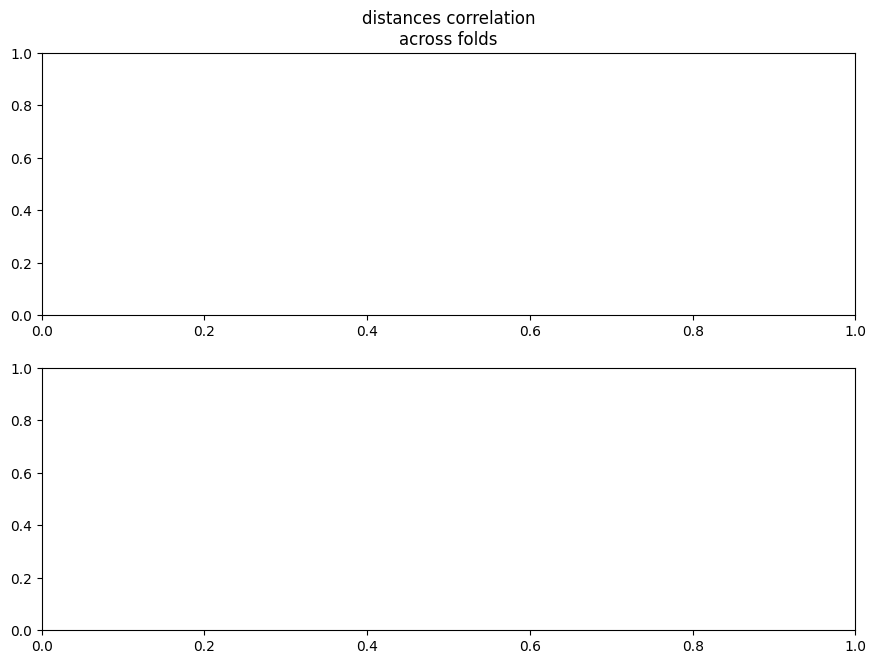

In [ ]:

colors = ['#4C72B0', '#03A6A6', '#88D94E', '#88D94E', '#F28D9F', '#F28D9F']

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7*1.5,5*1.5))

### Plot distribution of correlations for each region
axes[0].set_title("distances correlation\nacross folds")
data_corrs = np.array(all_c_corrs, dtype=object)
shuffle_corrs = np.array(all_c_corrs, dtype=object).mean()

vplot = axes[0].violinplot(data_corrs, tick_labels=regions, patch_artist=True)
for patch, color in zip(vplot['bodies'], colors):
    patch.set_facecolor(color)

axes[0].legend()
axes[0].set_ylabel("pearsonr\ncorrelation")
axes[0].set_yticks([0,0.25])
axes[0].set_ylim(0,0.25)
axes[0].set_xticks([])
plt.show()
#plt.savefig("../results_web_new/IBL_main_figure.svg",dpi=300)